<a href="https://colab.research.google.com/github/AaryanAnand10/Monte-Carlo-Simulation-With-Geometric-Brownian-Motion/blob/main/MonteCarlo_GBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 2 - Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# Cell 3 - Download stock data using yfinance
ticker   = "AAPL"       # Change to any stock ticker
start    = "2022-01-01"
end      = "2024-01-01"

data = yf.download(ticker, start=start, end=end)
close_prices = data["Close"].dropna()

print(f"✅ Downloaded {len(close_prices)} trading days of data for {ticker}")
print(close_prices.tail())


[*********************100%***********************]  1 of 1 completed

✅ Downloaded 501 trading days of data for AAPL
Ticker            AAPL
Date                  
2023-12-22  191.609467
2023-12-26  191.065109
2023-12-27  191.164108
2023-12-28  191.589661
2023-12-29  190.550476


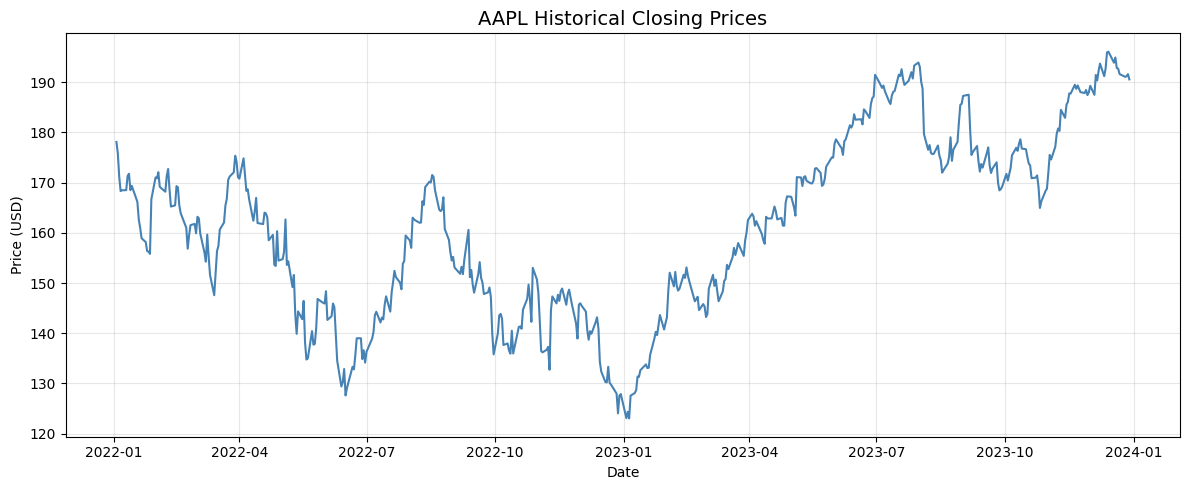

In [3]:
# Cell 4 - Plot historical closing prices
plt.figure(figsize=(12, 5))
plt.plot(close_prices, color="steelblue", linewidth=1.5)
plt.title(f"{ticker} Historical Closing Prices", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


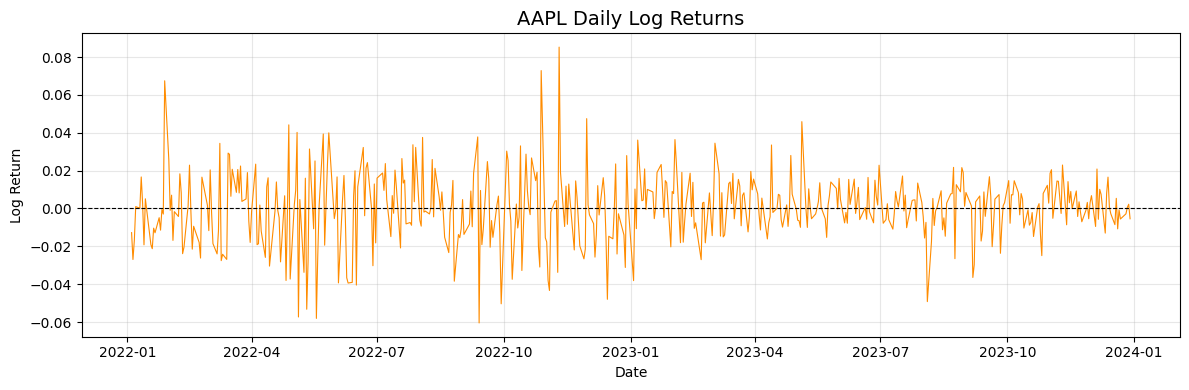

In [4]:
# Cell 5 - Compute daily log returns
# r_i = ln(S_i / S_{i-1})
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()

plt.figure(figsize=(12, 4))
plt.plot(log_returns, color="darkorange", linewidth=0.8)
plt.title(f"{ticker} Daily Log Returns", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
# Cell 6 - FIXED - Estimate GBM parameters from historical data
mu_daily    = float(log_returns.mean())        # ✅ cast to plain float
sigma_daily = float(log_returns.std())         # ✅ cast to plain float

# Annualize both
mu    = mu_daily * 252
sigma = sigma_daily * np.sqrt(252)

print("=" * 40)
print(f"📌 Ticker         : {ticker}")
print(f"📈 Daily Drift µ  : {mu_daily:.6f}")
print(f"📈 Annual Drift µ : {mu:.4f}  ({mu*100:.2f}%)")
print(f"📉 Daily Vol   σ  : {sigma_daily:.6f}")
print(f"📉 Annual Vol  σ  : {sigma:.4f}  ({sigma*100:.2f}%)")
print(f"\n🔍 Type check → mu: {type(mu)}, sigma: {type(sigma)}")
print("=" * 40)


📌 Ticker         : AAPL
📈 Daily Drift µ  : 0.000135
📈 Annual Drift µ : 0.0340  (3.40%)
📉 Daily Vol   σ  : 0.018295
📉 Annual Vol  σ  : 0.2904  (29.04%)

🔍 Type check → mu: <class 'float'>, sigma: <class 'numpy.float64'>


In [9]:
# Cell 7 - FIXED - Define Monte Carlo simulation parameters
S0  = float(close_prices.iloc[-1])   # ✅ cast to plain float
T   = 1                              # Time horizon in years
N   = 252                            # Number of time steps (trading days)
M   = 10000                          # Number of Monte Carlo paths
dt  = T / N                          # Size of each time step

print("=" * 40)
print(f"🔹 Starting Price S0 : ${S0:.2f}")
print(f"🔹 Time Horizon  T   : {T} Year(s)")
print(f"🔹 Time Steps    N   : {N}")
print(f"🔹 Simulations   M   : {M}")
print(f"🔹 Delta t (dt)      : {dt:.4f}")
print(f"\n🔍 Type check → S0: {type(S0)}")
print("=" * 40)


🔹 Starting Price S0 : $190.55
🔹 Time Horizon  T   : 1 Year(s)
🔹 Time Steps    N   : 252
🔹 Simulations   M   : 10000
🔹 Delta t (dt)      : 0.0040

🔍 Type check → S0: <class 'float'>


In [10]:
# Cell 8 - Simulate M price paths using GBM discrete formula:
# S(t+dt) = S(t) * exp((µ - σ²/2)*dt + σ*sqrt(dt)*Z)

np.random.seed(42)

# Matrix to store all simulated paths (N+1 rows x M columns)
price_paths = np.zeros((N + 1, M))
price_paths[0] = S0

# Generate all random shocks at once for efficiency
Z = np.random.standard_normal((N, M))

# Simulate step by step
for t in range(1, N + 1):
    price_paths[t] = price_paths[t - 1] * np.exp(
        (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[t - 1]
    )

print(f"✅ Simulation complete! Shape of price matrix: {price_paths.shape}")
print(f"   → {M} paths × {N+1} time steps")


✅ Simulation complete! Shape of price matrix: (253, 10000)
   → 10000 paths × 253 time steps


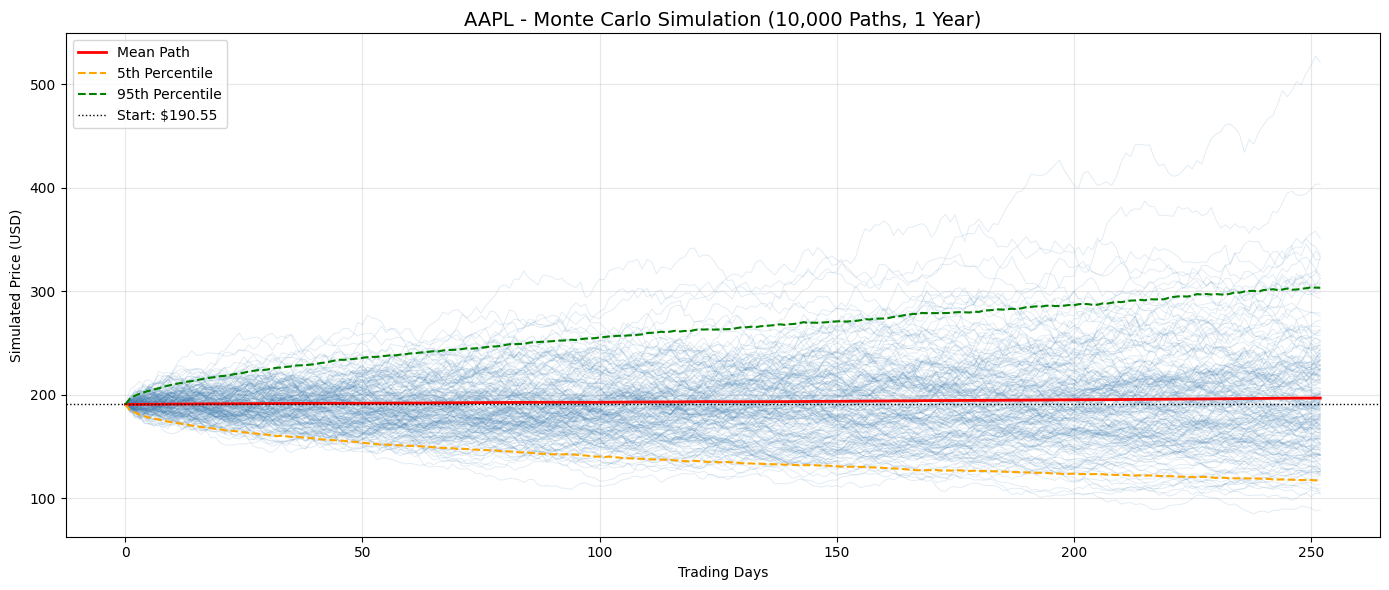

In [11]:
# Cell 9 - Plot a sample of simulated paths
plt.figure(figsize=(14, 6))

# Plot 200 random paths for clarity
sample_paths = np.random.choice(M, 200, replace=False)
for i in sample_paths:
    plt.plot(price_paths[:, i], alpha=0.15, linewidth=0.7, color="steelblue")

# Highlight key statistics
plt.plot(price_paths.mean(axis=1), color="red",    linewidth=2,   label="Mean Path")
plt.plot(np.percentile(price_paths, 5,  axis=1), color="orange", linewidth=1.5,
         linestyle="--", label="5th Percentile")
plt.plot(np.percentile(price_paths, 95, axis=1), color="green",  linewidth=1.5,
         linestyle="--", label="95th Percentile")

plt.title(f"{ticker} - Monte Carlo Simulation ({M:,} Paths, {T} Year)", fontsize=14)
plt.xlabel("Trading Days")
plt.ylabel("Simulated Price (USD)")
plt.axhline(S0, color="black", linewidth=1, linestyle=":", label=f"Start: ${S0:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


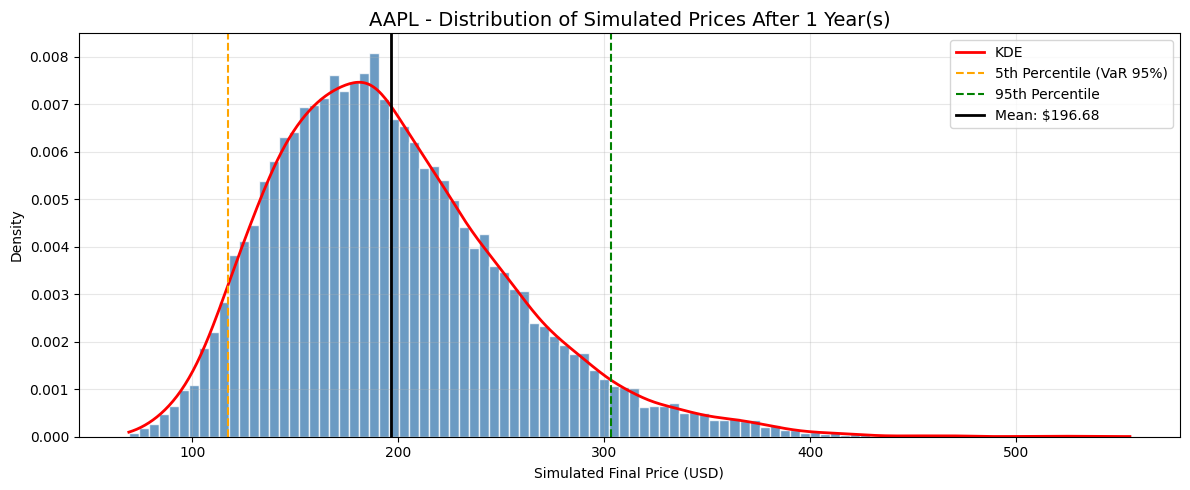

In [12]:
# Cell 10 - Distribution of final prices after T years
final_prices = price_paths[-1]

plt.figure(figsize=(12, 5))
plt.hist(final_prices, bins=100, color="steelblue", edgecolor="white",
         alpha=0.8, density=True)

# Overlay a KDE (smooth distribution curve)
from scipy.stats import gaussian_kde
kde = gaussian_kde(final_prices)
x   = np.linspace(final_prices.min(), final_prices.max(), 500)
plt.plot(x, kde(x), color="red", linewidth=2, label="KDE")

plt.axvline(np.percentile(final_prices, 5),  color="orange",
            linestyle="--", linewidth=1.5, label="5th Percentile (VaR 95%)")
plt.axvline(np.percentile(final_prices, 95), color="green",
            linestyle="--", linewidth=1.5, label="95th Percentile")
plt.axvline(final_prices.mean(), color="black",
            linestyle="-",  linewidth=2,   label=f"Mean: ${final_prices.mean():.2f}")

plt.title(f"{ticker} - Distribution of Simulated Prices After {T} Year(s)", fontsize=14)
plt.xlabel("Simulated Final Price (USD)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# Cell 11 - Summary statistics and risk metrics
mean_price   = np.mean(final_prices)
median_price = np.median(final_prices)
std_price    = np.std(final_prices)
min_price    = np.min(final_prices)
max_price    = np.max(final_prices)

# Percentiles
p5   = np.percentile(final_prices, 5)
p25  = np.percentile(final_prices, 25)
p75  = np.percentile(final_prices, 75)
p95  = np.percentile(final_prices, 95)

# Value at Risk (VaR) and Expected Shortfall (CVaR)
VaR_95  = S0 - p5
CVaR_95 = S0 - final_prices[final_prices <= p5].mean()

# Probability of profit
prob_profit = np.mean(final_prices > S0) * 100
prob_loss   = np.mean(final_prices < S0) * 100

print("=" * 50)
print(f"  📊 Monte Carlo Summary — {ticker}")
print("=" * 50)
print(f"  Starting Price       : ${S0:.2f}")
print(f"  Expected Price       : ${mean_price:.2f}")
print(f"  Median  Price        : ${median_price:.2f}")
print(f"  Std Deviation        : ${std_price:.2f}")
print("-" * 50)
print(f"  Min  Simulated Price : ${min_price:.2f}")
print(f"  Max  Simulated Price : ${max_price:.2f}")
print("-" * 50)
print(f"  5th  Percentile      : ${p5:.2f}")
print(f"  25th Percentile      : ${p25:.2f}")
print(f"  75th Percentile      : ${p75:.2f}")
print(f"  95th Percentile      : ${p95:.2f}")
print("-" * 50)
print(f"  VaR  (95% conf.)     : ${VaR_95:.2f}")
print(f"  CVaR (95% conf.)     : ${CVaR_95:.2f}")
print("-" * 50)
print(f"  Probability of Profit: {prob_profit:.2f}%")
print(f"  Probability of Loss  : {prob_loss:.2f}%")
print("=" * 50)


  📊 Monte Carlo Summary — AAPL
  Starting Price       : $190.55
  Expected Price       : $196.68
  Median  Price        : $188.84
  Std Deviation        : $57.97
--------------------------------------------------
  Min  Simulated Price : $69.21
  Max  Simulated Price : $555.10
--------------------------------------------------
  5th  Percentile      : $117.24
  25th Percentile      : $155.12
  75th Percentile      : $229.49
  95th Percentile      : $303.29
--------------------------------------------------
  VaR  (95% conf.)     : $73.31
  CVaR (95% conf.)     : $86.22
--------------------------------------------------
  Probability of Profit: 48.57%
  Probability of Loss  : 51.43%


In [14]:
# Cell 12 - Save simulation results to CSV
results_df = pd.DataFrame({
    "Metric"  : ["Start Price", "Expected Price", "Median Price",
                 "Std Dev", "5th Pct", "95th Pct",
                 "VaR 95%", "CVaR 95%",
                 "Prob Profit %", "Prob Loss %"],
    "Value"   : [S0, mean_price, median_price,
                 std_price, p5, p95,
                 VaR_95, CVaR_95,
                 prob_profit, prob_loss]
})

results_df.to_csv(f"{ticker}_monte_carlo_results.csv", index=False)
print(f"✅ Results saved to '{ticker}_monte_carlo_results.csv'")


✅ Results saved to 'AAPL_monte_carlo_results.csv'
